# 07. flow0 / flow2 분석

## 목적
관세청에서 수집한 flow0/flow2 데이터를 기반으로 **우회 수입 의심 패턴**을 탐지한다.

우회 의심 패턴:
- **flow0 감소**: 규제국 → 한국 직접 수입 감소
- **flow2 증가**: 제3국 → 한국 수입 증가

## 입력
- `data/interim/customs_flow0_flow2_raw.csv`

## 분석 순서
1. 데이터 로드 & 전처리 (trade_date 형식 수정 등)
2. 규제 전후 기간 구분
3. flow0 추이 분석 (규제국 → 한국)
4. flow2 추이 분석 (후보국 → 한국)
5. 우회 의심 이벤트 탐지 및 순위화
6. 이벤트별 시각화

## 0. 라이브러리 & 설정

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import pycountry
import seaborn as sns

# 한국어 폰트 설정 (macOS 기준)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("../data/interim")
INPUT_PATH = DATA_DIR / "customs_flow0_flow2_raw.csv"

## 1. 데이터 로드 & 전처리

In [2]:
df_raw = pd.read_csv(INPUT_PATH, dtype={"trade_date": "string"})

print("Shape:", df_raw.shape)
print("\nDtypes:")
print(df_raw.dtypes)
print("\nNull counts:")
print(df_raw.isnull().sum())

Shape: (141907, 17)

Dtypes:
trade_date                string
country_iso2                 str
country_name_kr              str
hs_code                    int64
imp_wgt                    int64
imp_dlr                    int64
hs_code_query              int64
window_start                 str
window_end                   str
flow                       int64
event_id                     str
source_row_id              int64
origin_country_name_kr       str
origin_country_iso3          str
product_name_kr              str
start_date                   str
end_date                     str
dtype: object

Null counts:
trade_date                 0
country_iso2              29
country_name_kr            0
hs_code                    0
imp_wgt                    0
imp_dlr                    0
hs_code_query              0
window_start               0
window_end                 0
flow                       0
event_id                   0
source_row_id              0
origin_country_name_kr     0
origi

In [3]:
df = df_raw.copy()

# trade_date: YYYY-MM 문자열 형식 (06에서 API 응답 원형 변환)
df["trade_date"] = pd.to_datetime(
    df["trade_date"], format="%Y-%m"
).dt.to_period("M")

# 날짜 컬럼 파싱
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# country_iso2 null 확인 (집계되지 않은 기타 국가 등)
print("country_iso2 null 행:")
print(df[df["country_iso2"].isnull()][["trade_date", "country_name_kr", "hs_code", "imp_dlr"]].head())

country_iso2 null 행:
      trade_date country_name_kr     hs_code  imp_dlr
63486    2017-07            나미비아  4810191000        0
63487    2017-07            나미비아  4810191000        0
63488    2017-07            나미비아  4810191000        0
63756    2017-08            나미비아  4810191000        0
63757    2017-08            나미비아  4810191000        0


In [4]:
# country_iso2가 null인 행은 '기타 국가' 등 집계 불가 행으로 제외
df = df[df["country_iso2"].notna()].copy()


def iso3_to_iso2(code: str) -> str | None:
    """pycountry를 사용해 ISO3 → ISO2 변환."""
    country = pycountry.countries.get(alpha_3=code)
    return country.alpha_2 if country else None


# source_row_id별 규제국 집합 기준으로 flow0/flow2 재분류
regulated_pairs = (
    df[["source_row_id", "origin_country_iso3"]]
    .drop_duplicates()
    .assign(country_iso2=lambda x: x["origin_country_iso3"].map(iso3_to_iso2))
    .dropna(subset=["country_iso2"])
    [["source_row_id", "country_iso2"]]
    .assign(is_regulated=True)
)

df = df.merge(regulated_pairs, on=["source_row_id", "country_iso2"], how="left")
df["flow_corrected"] = (
    df["is_regulated"]
    .fillna(False)
    .map({True: 0, False: 2})
    .astype(int)
)
df = df.drop(columns="is_regulated")

print("전처리 후 Shape:", df.shape)
print("기존 flow 분포:")
print(df["flow"].value_counts())
print("\n보정 flow 분포:")
print(df["flow_corrected"].value_counts())
print("\nold flow0 → corrected flow2 행:", int(((df["flow"] == 0) & (df["flow_corrected"] == 2)).sum()))

전처리 후 Shape: (141878, 18)
기존 flow 분포:
flow
2    123899
0     17979
Name: count, dtype: int64

보정 flow 분포:
flow_corrected
2    126405
0     15473
Name: count, dtype: int64

old flow0 → corrected flow2 행: 2506


## 2. 규제 전후 기간 구분

각 행에 **규제 전(before)** / **규제 후(after)** 레이블을 붙인다.

- `before`: `trade_date < start_date` (규제 시작 전)
- `after`: `trade_date >= start_date` (규제 시작 후)

In [5]:
# trade_date(Period)와 start_date(Timestamp) 비교를 위해 start_date를 Period로 변환
df["start_period"] = df["start_date"].dt.to_period("M")
df["period_label"] = (df["trade_date"] >= df["start_period"]).map(
    {True: "after", False: "before"}
)

print("기간 레이블 분포:")
print(df["period_label"].value_counts())

기간 레이블 분포:
period_label
after     71338
before    70540
Name: count, dtype: int64


## 3. flow0 분석 — 규제국 → 한국

**분석 단위: `source_row_id` (규제 사건)**

같은 규제 사건에 여러 규제국이 있는 경우(예: 에탄올아민 — 미국·말레이시아·태국·일본)
모든 규제국으로부터의 수입을 합산해서 "규제 전체 채널"로 본다.

In [6]:
df_f0 = df[df["flow_corrected"] == 0].copy()

# source_row_id × trade_date × period_label 기준으로 모든 규제국 수입 합산 (월별)
f0_monthly = (
    df_f0
    .groupby(["source_row_id", "product_name_kr", "trade_date", "period_label"])
    .agg(
        total_imp_dlr=("imp_dlr", "sum"),
        total_imp_wgt=("imp_wgt", "sum"),
        regulated_countries=("origin_country_name_kr", lambda x: "·".join(sorted(set(x)))),
    )
    .reset_index()
)

# 규제 전후 월평균으로 집계
f0_summary = (
    f0_monthly
    .groupby(["source_row_id", "product_name_kr", "regulated_countries", "period_label"])
    .agg(avg_imp_dlr=("total_imp_dlr", "mean"))
    .reset_index()
)

f0_wide = f0_summary.pivot_table(
    index=["source_row_id", "product_name_kr", "regulated_countries"],
    columns="period_label",
    values="avg_imp_dlr",
).reset_index()
f0_wide.columns.name = None

f0_wide["dlr_change_pct"] = (
    (f0_wide["after"] - f0_wide["before"]) / f0_wide["before"].replace(0, float("nan"))
) * 100

f0_wide = f0_wide.sort_values("dlr_change_pct")
print("flow0 규제 전후 월평균 수입금액 변화 (감소폭 큰 순):")
f0_wide[["source_row_id", "product_name_kr", "regulated_countries", "before", "after", "dlr_change_pct"]]

flow0 규제 전후 월평균 수입금액 변화 (감소폭 큰 순):


,source_row_id,product_name_kr,regulated_countries,before,after,dlr_change_pct
4,6,초산에틸,인도,3.539289e+05,0.000000e+00,-100.000000
47,49,백시멘트,이집트,1.819151e+05,3.100000e+01,-99.982959
54,57,스테인리스강 냉간압연제품,베트남,1.682798e+07,2.147643e+05,-98.723766
8,10,부틸글리콜에테르,미국·프랑스,3.321554e+06,1.230582e+05,-96.295163
39,41,부틸글리콜에테르,사우디아라비아,1.203452e+06,7.560483e+04,-93.717670
56,59,스테인리스스틸 후판,중국,2.664690e+06,9.306830e+05,-65.073492
17,19,에탄올아민(1차재심),말레이시아·미국·일본·태국,8.572027e+05,3.080923e+05,-64.058405
58,61,파티클보드,태국,8.108333e+06,3.057371e+06,-62.293468
20,22,스테인리스스틸바,대만·이탈리아,4.195755e+06,1.812266e+06,-56.807160
26,28,스테인리스스틸 후판,일본,5.383008e+06,2.620925e+06,-51.311153


## 4. flow2 분석 — 후보국 → 한국

**분석 단위: `source_row_id` (규제 사건)**

같은 규제 사건에 여러 event_id가 있으면 flow2 데이터가 중복 저장되어 있다.
`source_row_id × trade_date × country_iso2` 기준으로 중복을 제거한 뒤 집계한다.

In [7]:
df_f2 = df[df["flow_corrected"] == 2].copy()

# 중복 제거: 같은 source_row_id의 여러 event_id가 동일한 flow2 데이터를 가지므로
# (source_row_id, trade_date, country_iso2) 기준으로 첫 번째 행만 유지
df_f2_dedup = (
    df_f2
    .drop_duplicates(subset=["source_row_id", "trade_date", "country_iso2", "hs_code"])
    .copy()
)

print(f"중복 제거 전: {len(df_f2):,}행 → 제거 후: {len(df_f2_dedup):,}행")

# Step 1: trade_date 기준 월별 합산
f2_monthly = (
    df_f2_dedup
    .groupby(
        ["source_row_id", "product_name_kr", "country_iso2", "country_name_kr",
         "trade_date", "period_label"]
    )
    .agg(monthly_imp_dlr=("imp_dlr", "sum"))
    .reset_index()
)

# Step 2: 월평균 수입금액 (월별 합산값의 평균)
f2_summary = (
    f2_monthly
    .groupby(["source_row_id", "product_name_kr", "country_iso2", "country_name_kr", "period_label"])
    .agg(avg_imp_dlr=("monthly_imp_dlr", "mean"))
    .reset_index()
)

f2_wide = f2_summary.pivot_table(
    index=["source_row_id", "product_name_kr", "country_iso2", "country_name_kr"],
    columns="period_label",
    values="avg_imp_dlr",
).reset_index()
f2_wide.columns.name = None

f2_wide["before"] = f2_wide.get("before", 0).fillna(0)
f2_wide["after"] = f2_wide.get("after", 0).fillna(0)
f2_wide["dlr_change_pct"] = (
    (f2_wide["after"] - f2_wide["before"]) / f2_wide["before"].replace(0, float("nan"))
) * 100
f2_wide["dlr_change_abs"] = f2_wide["after"] - f2_wide["before"]

print("\nflow2 규제 전후 월평균 수입금액 증가 상위 15개 (후보국):")
f2_wide.sort_values("dlr_change_abs", ascending=False).head(15)[
    ["source_row_id", "product_name_kr", "country_name_kr", "before", "after", "dlr_change_abs", "dlr_change_pct"]
]

중복 제거 전: 126,405행 → 제거 후: 69,711행

flow2 규제 전후 월평균 수입금액 증가 상위 15개 (후보국):


,source_row_id,product_name_kr,country_name_kr,before,after,dlr_change_abs,dlr_change_pct
3573,60,탄소강과 그밖의 합금강 열간압연 후판제품,일본,3.659549e+07,4.558668e+07,8.991183e+06,24.569099
2238,36,스테인리스평판압연,베트남,1.225162e+05,7.840196e+06,7.717680e+06,6299.315213
3142,52,합판,러시아 연방,4.491799e+06,1.019615e+07,5.704353e+06,126.994856
3055,50,합판,러시아 연방,4.491799e+06,1.019615e+07,5.704353e+06,126.994856
3216,53,합판,러시아 연방,4.491799e+06,1.019615e+07,5.704353e+06,126.994856
3615,61,파티클보드,중국,2.547659e+06,7.969222e+06,5.421563e+06,212.805672
856,15,페로실리코망간,말레이시아,5.479882e+06,1.038987e+07,4.909987e+06,89.600235
2198,36,스테인리스평판압연,일본,1.054390e+07,1.481850e+07,4.274603e+06,40.541018
730,12,합판(1차재심),베트남,1.180428e+07,1.580037e+07,3.996085e+06,33.852842
637,11,합판(2차재심),베트남,1.180428e+07,1.580037e+07,3.996085e+06,33.852842


## 5. 우회 의심 이벤트 탐지

**우회 의심 조건**:
- flow0 감소 (`dlr_change_pct < 0`)
- flow2 증가 국가가 1개 이상 존재 (`dlr_change_abs > 0`)

두 조건을 동시에 만족하는 이벤트를 추출하고,
flow0 감소폭 × flow2 최대 증가폭으로 우선순위를 산정한다.

In [8]:
# flow0가 감소한 규제 사건
f0_decreased = f0_wide[f0_wide["dlr_change_pct"] < 0][
    ["source_row_id", "product_name_kr", "regulated_countries", "dlr_change_pct"]
].rename(columns={"dlr_change_pct": "f0_change_pct"})

# 사건별 flow2 최대 증가 후보국
f2_top = (
    f2_wide[f2_wide["dlr_change_abs"] > 0]
    .sort_values("dlr_change_abs", ascending=False)
    .groupby("source_row_id")
    .first()
    .reset_index()[["source_row_id", "country_name_kr", "dlr_change_abs", "dlr_change_pct"]]
    .rename(columns={
        "country_name_kr": "top_intermediary",
        "dlr_change_abs": "f2_top_change_abs",
        "dlr_change_pct": "f2_top_change_pct",
    })
)

# 두 조건 교집합
suspects = f0_decreased.merge(f2_top, on="source_row_id", how="inner")

# 규제 시작일 추가
start_meta = df[["source_row_id", "start_date"]].drop_duplicates("source_row_id")
suspects = suspects.merge(start_meta, on="source_row_id", how="left")

# suspicion_score: flow0 감소폭(절댓값) + flow2 최대 증가율
suspects["suspicion_score"] = suspects["f0_change_pct"].abs() + suspects["f2_top_change_pct"].fillna(0)
suspects = suspects.sort_values("suspicion_score", ascending=False).reset_index(drop=True)

print(f"전체 규제 사건: {f0_wide['source_row_id'].nunique()}건")
print(f"우회 의심 사건: {len(suspects)}건")
print()
suspects[[
    "source_row_id", "product_name_kr", "regulated_countries",
    "start_date", "f0_change_pct", "top_intermediary",
    "f2_top_change_pct", "suspicion_score"
]]

전체 규제 사건: 60건
우회 의심 사건: 40건



,source_row_id,product_name_kr,regulated_countries,start_date,f0_change_pct,top_intermediary,f2_top_change_pct,suspicion_score
0,40,부틸글리콜에테르,미국·프랑스,2022-07-26,-2.497582,대만,800121.978022,800124.475604
1,41,부틸글리콜에테르,사우디아라비아,2022-09-05,-93.717670,대만,19755.479452,19849.197122
2,23,초산에틸(3차재심),싱가포르·일본·중국,2019-07-09,-49.266730,남아프리카공화국,19075.390625,19124.657355
3,36,스테인리스평판압연,대만·인도네시아·중국,2021-09-15,-32.728130,베트남,6299.315213,6332.043344
4,1,플로트판유리(2차재심),중국,2015-01-07,-12.251252,튀르키예,2148.812102,2161.063354
5,10,부틸글리콜에테르,미국·프랑스,2016-12-06,-96.295163,사우디아라비아,829.311058,925.606221
6,57,스테인리스강 냉간압연제품,베트남,2025-07-11,-98.723766,말레이시아,590.315884,689.039651
7,56,스테인리스강 평판압연제품,대만·인도네시아·중국,2025-05-16,-5.819684,말레이시아,412.126906,417.946590
8,61,파티클보드,태국,2025-12-05,-62.293468,중국,212.805672,275.099140
9,43,폴리아미드필름,인도네시아·중국·태국,2023-02-27,-13.879973,대만,252.445430,266.325403


## 6. 이벤트별 시계열 시각화

우회 의심 점수 상위 이벤트에 대해 flow0 / flow2 시계열을 그린다.

- 상단 패널: flow0 (규제국 → 한국) 수입금액 추이
- 하단 패널: flow2 상위 3개 후보국 → 한국 수입금액 추이
- 수직 점선: 규제 시작일

In [9]:
def plot_case(source_row_id: int, df: pd.DataFrame, top_n_intermediary: int = 3):
    """규제 사건(source_row_id) 1건의 flow0/flow2 시계열을 시각화."""
    df_case = df[df["source_row_id"] == source_row_id].copy()

    product = df_case["product_name_kr"].iloc[0]
    regulated = "·".join(sorted(df_case["origin_country_name_kr"].unique()))
    start_date = df_case["start_date"].iloc[0]

    # flow0: 모든 규제국 수입 합산
    df_f0 = (
        df_case[df_case["flow_corrected"] == 0]
        .groupby("trade_date")["imp_dlr"]
        .sum()
        .reset_index()
        .sort_values("trade_date")
    )

    # flow2: 중복 제거 후 상위 N개 후보국
    df_f2 = (
        df_case[df_case["flow_corrected"] == 2]
        .drop_duplicates(subset=["trade_date", "country_iso2", "hs_code"])
        .copy()
    )
    top_countries = (
        df_f2.groupby("country_name_kr")["imp_dlr"]
        .sum()
        .nlargest(top_n_intermediary)
        .index.tolist()
    )
    df_f2_top = (
        df_f2[df_f2["country_name_kr"].isin(top_countries)]
        .groupby(["trade_date", "country_name_kr"])["imp_dlr"]
        .sum()
        .reset_index()
        .sort_values("trade_date")
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(
        f"source_row_id={source_row_id} | {product}\n규제국: {regulated}",
        fontsize=12, fontweight="bold"
    )

    ax0 = axes[0]
    if not df_f0.empty:
        ax0.plot(
            df_f0["trade_date"].astype(str), df_f0["imp_dlr"],
            color="steelblue", marker="o", markersize=3, linewidth=1.5,
        )
    ax0.axvline(str(start_date.to_period("M")), color="red", linestyle="--", linewidth=1.2, label="규제 시작")
    ax0.set_title("flow0: 규제국(합산) → 한국 (수입금액, USD)", fontsize=10)
    ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax0.legend(fontsize=8)
    ax0.grid(axis="y", alpha=0.3)

    ax1 = axes[1]
    palette = sns.color_palette("tab10", n_colors=top_n_intermediary)
    for idx, country in enumerate(top_countries):
        sub = df_f2_top[df_f2_top["country_name_kr"] == country]
        ax1.plot(
            sub["trade_date"].astype(str), sub["imp_dlr"],
            marker="o", markersize=3, linewidth=1.5,
            color=palette[idx], label=country,
        )
    ax1.axvline(str(start_date.to_period("M")), color="red", linestyle="--", linewidth=1.2)
    ax1.set_title(f"flow2: 후보국 상위 {top_n_intermediary}개국 → 한국 (수입금액, USD)", fontsize=10)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax1.legend(fontsize=8)
    ax1.grid(axis="y", alpha=0.3)

    all_dates = df_f0["trade_date"].astype(str).tolist()
    tick_labels = [all_dates[i] for i in range(0, len(all_dates), 6)]
    ax1.set_xticks(tick_labels)
    ax1.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

    plt.tight_layout()
    plt.show()

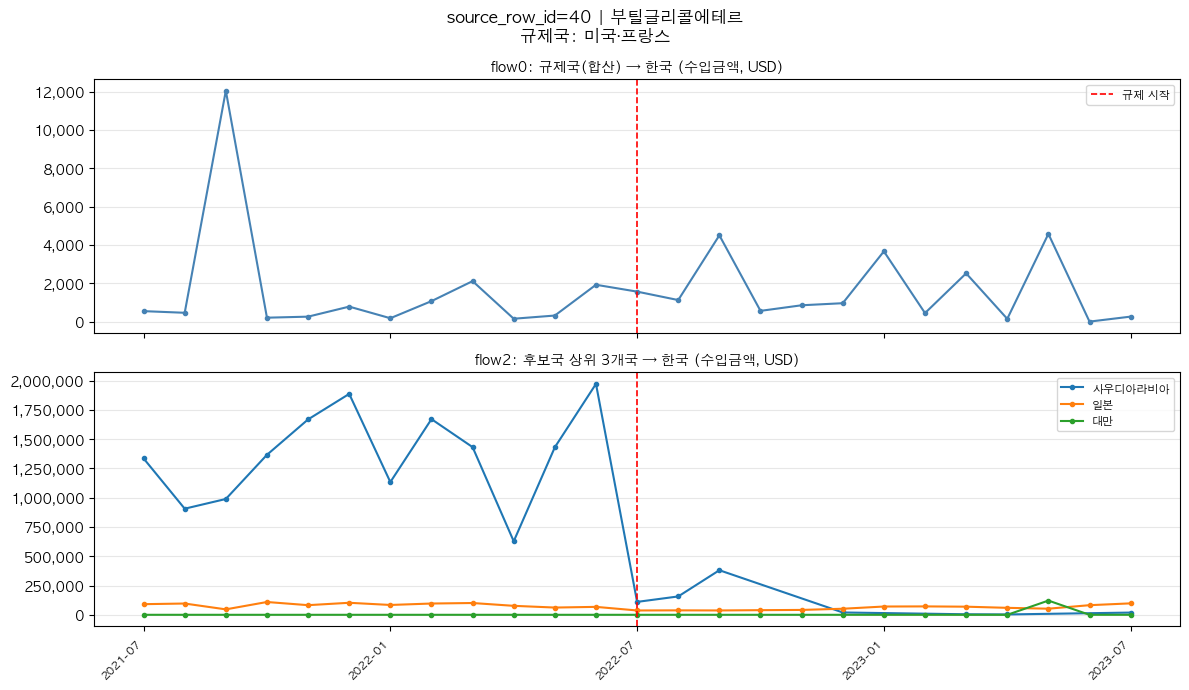

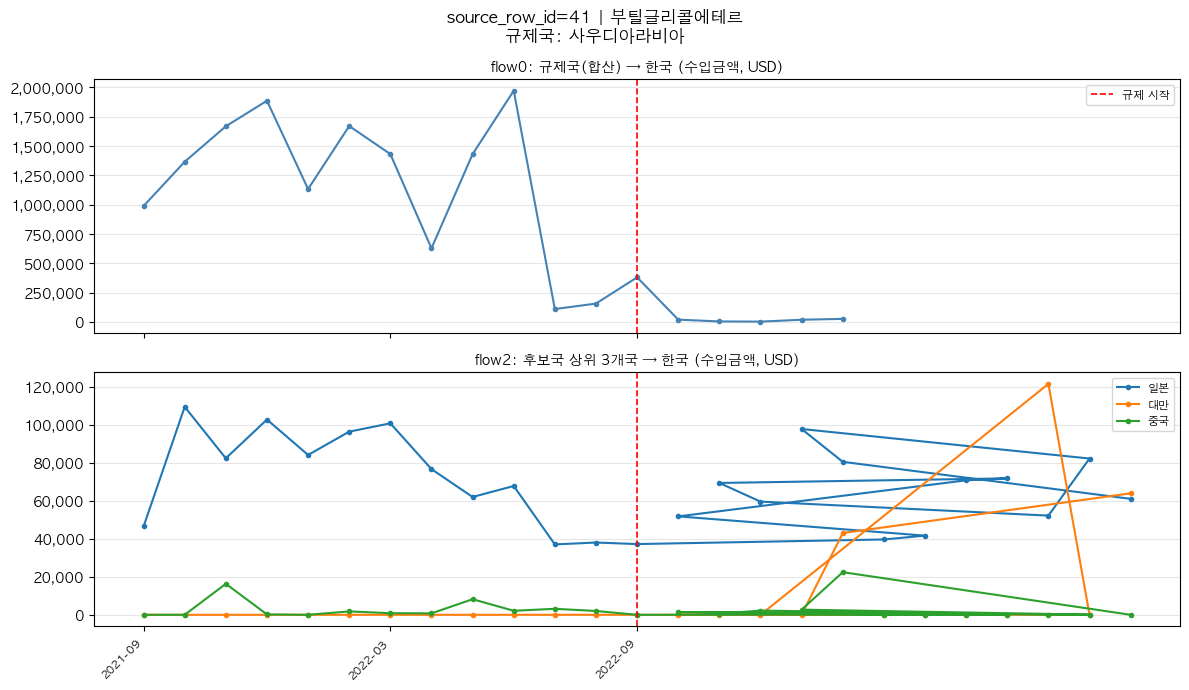

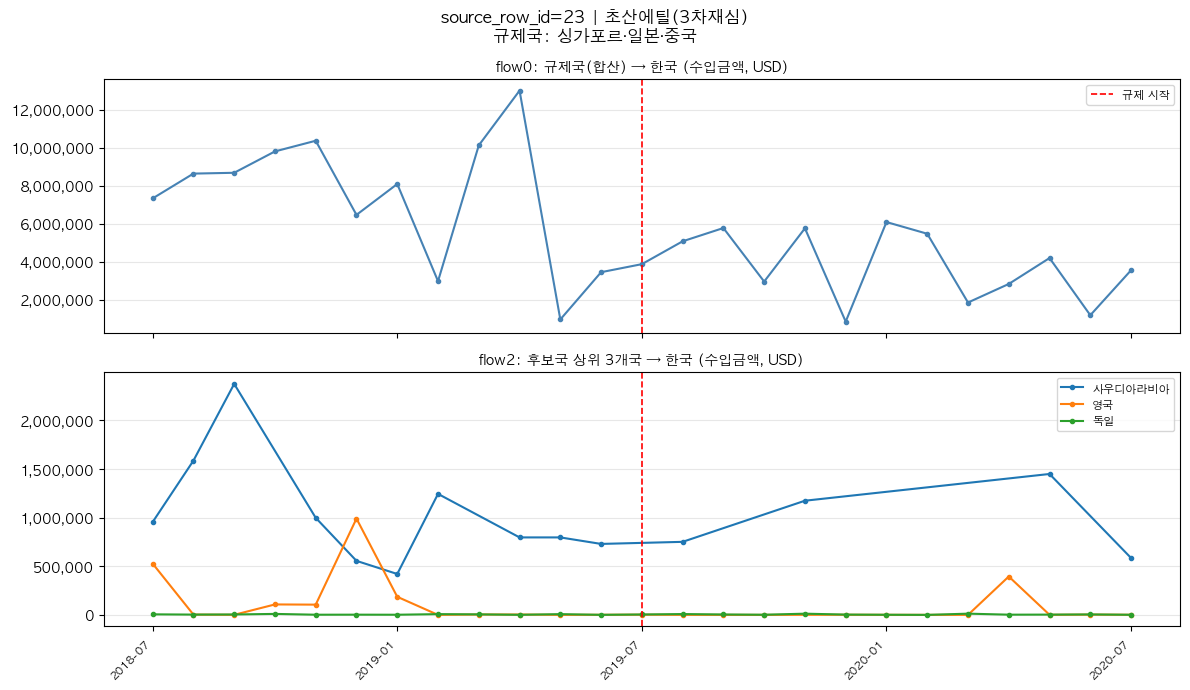

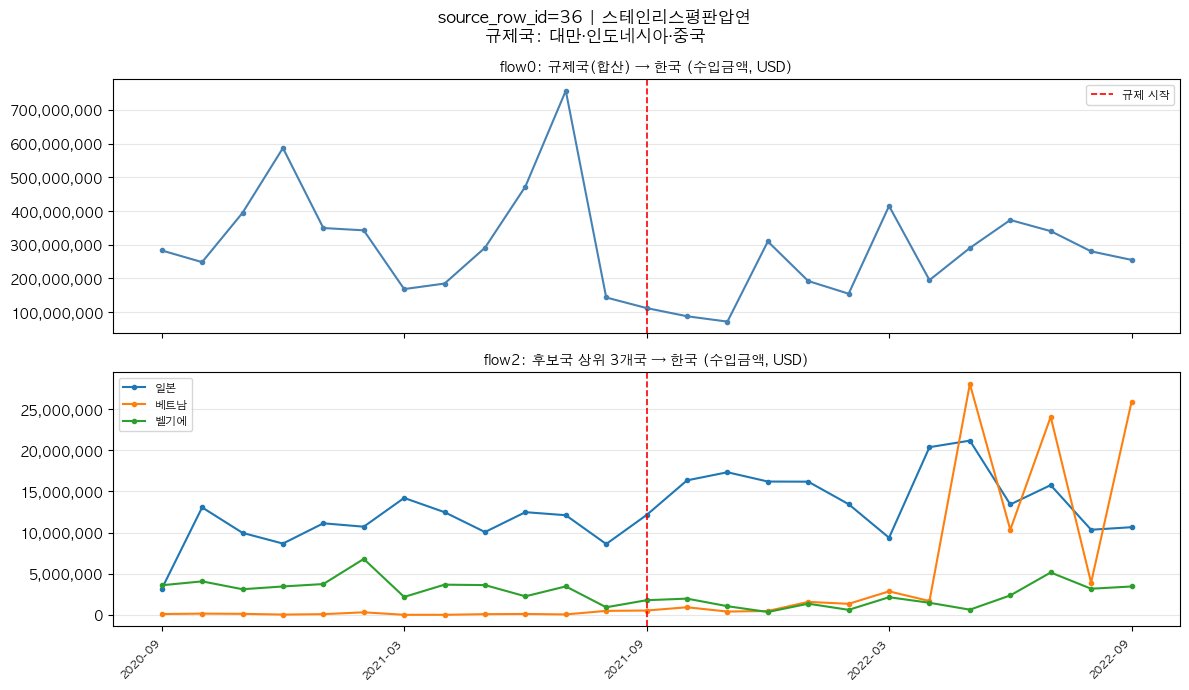

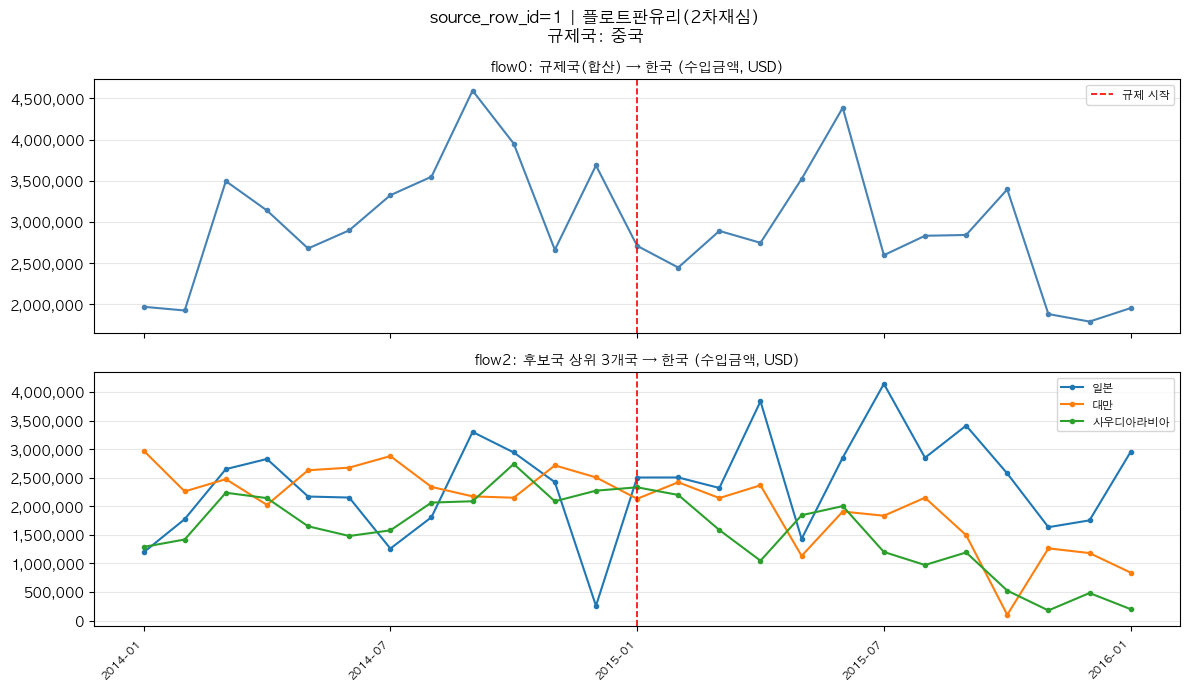

In [10]:
# 우회 의심 점수 상위 5개 사건 시각화
TOP_N = 5
top_cases = suspects["source_row_id"].head(TOP_N).tolist()

for sid in top_cases:
    plot_case(sid, df)

## 7. 요약

우회 의심 이벤트 목록과 주요 수치를 정리한다.

In [11]:
print("=" * 65)
print("우회 의심 사건 요약 (source_row_id 기준)")
print("=" * 65)
print(f"전체 규제 사건: {f0_wide['source_row_id'].nunique()}건")
print(f"우회 의심 사건: {len(suspects)}건")
print()
print(
    suspects[[
        "source_row_id", "product_name_kr", "regulated_countries",
        "f0_change_pct", "top_intermediary", "f2_top_change_pct", "suspicion_score"
    ]]
    .rename(columns={
        "product_name_kr": "품목",
        "regulated_countries": "규제국",
        "f0_change_pct": "flow0변화(%)",
        "top_intermediary": "주요후보국",
        "f2_top_change_pct": "flow2변화(%)",
        "suspicion_score": "의심점수",
    })
    .to_string(index=False)
)

우회 의심 사건 요약 (source_row_id 기준)
전체 규제 사건: 60건
우회 의심 사건: 40건

 source_row_id                                   품목            규제국  flow0변화(%)     주요후보국    flow2변화(%)          의심점수
            40                             부틸글리콜에테르         미국·프랑스   -2.497582        대만 800121.978022 800124.475604
            41                             부틸글리콜에테르        사우디아라비아  -93.717670        대만  19755.479452  19849.197122
            23                           초산에틸(3차재심)     싱가포르·일본·중국  -49.266730  남아프리카공화국  19075.390625  19124.657355
            36                            스테인리스평판압연    대만·인도네시아·중국  -32.728130       베트남   6299.315213   6332.043344
             1                         플로트판유리(2차재심)             중국  -12.251252      튀르키예   2148.812102   2161.063354
            10                             부틸글리콜에테르         미국·프랑스  -96.295163   사우디아라비아    829.311058    925.606221
            57                        스테인리스강 냉간압연제품            베트남  -98.723766     말레이시아    590.315884    689.039651
    